In [1]:
#Importing necessary packages
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import pickle
import torch.nn.functional as F

In [2]:
torch.manual_seed(7)
np.random.seed(7)

In [3]:
dtype = torch.float32
np_dtype = np.float32

In [4]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(device)

mps


In [5]:
class dataset(Dataset):
  def __init__(self,x,y,device):
    self.x = torch.from_numpy(x.astype(np_dtype)).to(device)
    self.y = torch.from_numpy(y.astype(np_dtype)).to(device)
    self.length = self.x.shape[0]
 
  def __getitem__(self,idx):
    return self.x[idx],self.y[idx]
  def __len__(self):
    return self.length

In [6]:
import torch
import torch.nn as nn
import numpy as np

# Make sure to choose your device (e.g., "cuda" if available)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

A = torch.eye(3,device=device)
A[1]*=0
print(A)

def train_multistep(model, trainloader, lr, weight_decay, epochs, device):
    """
    Trains the model using multi-step rollouts so that error accumulation is penalized.
    Each batch from the loader is a pair of tensors (x, y) of shape (B, 3, seq_len), where:
      - For a given sample i:
            x[i, :, 0] is the initial condition,
            y[i, :, t] is the true state at time step t+1 for t in 0 to seq_len-1.
    
    The model (with its forward performing one RK4 step) is rolled out repeatedly starting
    from the initial state, and the loss is accumulated over the full rollout.
    """
    model.to(device)
    model.train()
    
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    
    # Optionally, you can configure a learning rate scheduler here.
    # For example, a cyclic scheduler:
    max_lr = 1e-2
    min_lr = 1e-4
    steps = len(trainloader)*epochs
    scheduler = torch.optim.lr_scheduler.OneCycleLR(
                optimizer,
                max_lr=max_lr,
                div_factor= max_lr / min_lr,
                total_steps=steps,
                steps_per_epoch=len(trainloader),
                pct_start=0.5,
                anneal_strategy="cos",
            )
    
    for epoch in range(1, epochs + 1):
        total_loss = 0.0
        num_batches = 0
        
        for x, y in trainloader:
            # x and y are expected to have shape (batch, 3, seq_len)
            x, y = x.to(device), y.to(device)
            
            # Reset the optimizer gradients.
            optimizer.zero_grad()
            
            # Initialize current_state from the first time step of the input sequences.
            # This is the initial condition for the rollout.
            current_state = x[:, :, 0]  # shape: (batch, 3)
            loss = 0.0
            
            # Roll out the model over the sequence.
            seq_len = x.size(2)
            for t in range(seq_len):
                # Each call to model produces one RK4 integration step.
                prediction = model(current_state)  # shape: (batch, 3)
                # Compare the prediction with the ground truth for this time step.
                # y[:, :, t] corresponds to the state at time t+1.
                loss += criterion(prediction @ A, y[:, :, t] @ A)
                # Update current_state for the next iteration in the rollout.
                current_state = prediction
            
            # Optionally average loss over the sequence:
            loss = loss / seq_len
            
            loss.backward()
            optimizer.step()
            scheduler.step()  # Update scheduler per batch if using cyclic scheduling.
            
            total_loss += loss.item()
            num_batches += 1

        avg_loss = total_loss / num_batches
        if epoch == 1 or epoch % 50 == 0:
            print(f"Epoch [{epoch}/{epochs}] - Average Loss: {avg_loss:.6f}")

    print("Training complete.")


tensor([[1., 0., 0.],
        [0., 0., 0.],
        [0., 0., 1.]])


In [7]:
data_train = np.load("lorenz_training.npy")
data_test = np.load("lorenz_truth.npy")

In [8]:
from torch.utils.data import TensorDataset, DataLoader

def create_lorenz_dataloaders(data_train, data_test, seq_len=2, batch_size=128):
    """
    Split data into training and testing DataLoaders for a time-series-like dataset,
    where each sample is a sequence of consecutive time steps.

    Each sample consists of an input X and target Y where:
      - X[i] = data[i : i+seq_len]
      - Y[i] = data[i+1 : i+seq_len+1]
      
    The input X and the target Y are transposed to shape (D, seq_len), 
    so that overall they are tensors of shape (num_samples, D, seq_len).
    
    Args:
      data (np.array): Array of shape (T, D) containing the time-series data,
                       where T is the number of time steps and D is the feature dimension.
      train_ratio (float): Fraction of data used for training. The remainder is for testing.
      seq_len (int): Number of time steps in each sequence.
      batch_size (int): Batch size for the DataLoader.
      
    Returns:
      train_loader, test_loader: DataLoaders for training and testing.
    """
    T, D = data_train.shape  # T time steps, D features (e.g., D=3 for 3D points)
    
    # Determine split index for training (make sure the training set can support an entire sequence)
    N_train = T
    # Adjust so that we can extract windows of length seq_len+1 for training
    if N_train < seq_len + 1:
        raise ValueError("Not enough data points for the specified sequence length in the training set.")

    # --- Construct training examples ---
    # For training, we can iterate from 0 to N_train - seq_len - 1 so that X[i+seq_len] exists.
    train_x = [data_train[i : i + seq_len] for i in range(0, N_train - seq_len)]
    train_y = [data_train[i + 1 : i + seq_len + 1] for i in range(0, N_train - seq_len)]
    
    # Convert lists to numpy arrays
    # Now each sample is (seq_len, D)
    train_x = np.array(train_x)
    train_y = np.array(train_y)
    
    # Transpose each sample to have shape (D, seq_len)
    # The resulting tensor shape will be (num_train_samples, D, seq_len)
    train_x = np.transpose(train_x, (0, 2, 1))
    train_y = np.transpose(train_y, (0, 2, 1))
    
    # --- Construct testing examples ---
    
    T_test, D_test = data_test.shape  # T time steps, D features (e.g., D=3 for 3D points)
    
    # Determine split index for training (make sure the training set can support an entire sequence)
    N_test = T_test
    
    test_x = [data_test[i : i + seq_len] for i in range(0, T_test - seq_len)]
    test_y = [data_test[i + 1 : i + seq_len + 1] for i in range(0, T_test - seq_len)]
    
    test_x = np.array(test_x)
    test_y = np.array(test_y)
    
    test_x = np.transpose(test_x, (0, 2, 1))
    test_y = np.transpose(test_y, (0, 2, 1))
    
    # Convert to torch tensors
    x_train_t = torch.from_numpy(train_x).float()
    y_train_t = torch.from_numpy(train_y).float()
    x_test_t  = torch.from_numpy(test_x).float()
    y_test_t  = torch.from_numpy(test_y).float()
    
    # Build TensorDatasets and DataLoaders
    train_dataset = TensorDataset(x_train_t, y_train_t)
    test_dataset  = TensorDataset(x_test_t, y_test_t)
    
    train_loader  = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    test_loader   = DataLoader(test_dataset, batch_size=len(test_dataset), shuffle=False)
    
    return train_loader, test_loader

train_loader, test_loader = create_lorenz_dataloaders(data_train, data_test, batch_size=128)

In [9]:
class network(nn.Module):
    def __init__(self,n_layers,dim,h,dt):
        super().__init__()
        
        self.dim = dim
        self.h = h
        self.lift = nn.Linear(self.dim,self.h)
        self.n_layers = n_layers
        if self.n_layers>2:
            self.linears = nn.ModuleList([
                nn.Linear(self.h,self.h)
                for _ in range(self.n_layers - 2)
            ])
        self.proj = nn.Linear(self.h,self.dim)
        self.act = nn.LeakyReLU()
        self.dt = dt
        
    def vecField(self,X):
        X = self.act(self.lift(X))
        if self.n_layers>2:
            for i in range(self.n_layers-2):
                X = self.act(self.linears[i](X))
        output = self.proj(X)
        return output
        
    def forward(self,U):
        """
        Performs one integration step using the RK4 method.
        
        Given a state U, we compute:
        
          k1 = f(U)
          k2 = f(U + 0.5 * dt * k1)
          k3 = f(U + 0.5 * dt * k2)
          k4 = f(U + dt * k3)
          
          U_next = U + dt/6 * (k1 + 2*k2 + 2*k3 + k4)
        """
        dt = self.dt
        
        # Compute the four slopes
        k1 = self.vecField(U)
        k2 = self.vecField(U + 0.5 * dt * k1)
        k3 = self.vecField(U + 0.5 * dt * k2)
        k4 = self.vecField(U + dt * k3)
        
        # Return the updated state according to the RK4 formula
        U_next = U + (dt / 6) * (k1 + 2 * k2 + 2 * k3 + k4)
        return U_next

In [10]:
n_layers = 5
dt = 0.01
hidden_dimension = 50
model = network(n_layers=n_layers,
                dt=dt,
                h=hidden_dimension,
                dim=3)
model.to(device);

In [11]:
lr = 1e-2
weight_decay = 0
epochs = 1000
is_train = input("Do you want to train the model? y for yes, anyother key otherwise")=="y"
model_name = "trained_model_lorenz.pt"
if is_train:
    loss = train_multistep(model, train_loader, lr, weight_decay, epochs, device)
else:
    model.load_state_dict(torch.load(model_name, weights_only=True))

Epoch [1/1000] - Average Loss: 1.413558
Epoch [50/1000] - Average Loss: 0.053190
Epoch [100/1000] - Average Loss: 0.005244
Epoch [150/1000] - Average Loss: 0.003025
Epoch [200/1000] - Average Loss: 0.002511
Epoch [250/1000] - Average Loss: 0.005600
Epoch [300/1000] - Average Loss: 0.060865
Epoch [350/1000] - Average Loss: 0.001836
Epoch [400/1000] - Average Loss: 0.000438
Epoch [450/1000] - Average Loss: 0.000276
Epoch [500/1000] - Average Loss: 0.000319
Epoch [550/1000] - Average Loss: 0.000320
Epoch [600/1000] - Average Loss: 0.001204
Epoch [650/1000] - Average Loss: 0.000387
Epoch [700/1000] - Average Loss: 0.000508
Epoch [750/1000] - Average Loss: 0.000157
Epoch [800/1000] - Average Loss: 0.000227
Epoch [850/1000] - Average Loss: 0.000067
Epoch [900/1000] - Average Loss: 0.000042
Epoch [950/1000] - Average Loss: 0.000035
Epoch [1000/1000] - Average Loss: 0.000031
Training complete.


In [12]:
torch.save(model.state_dict(), "trained_model_lorenz.pt")

(5001, 3)


/var/folders/dj/7f6tf39966b0v9zczs10jg_40000gn/T/ipykernel_6667/1186026969.py:17: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/utils/tensor_new.cpp:257.)
  state = torch.tensor([data[0]], device=device)


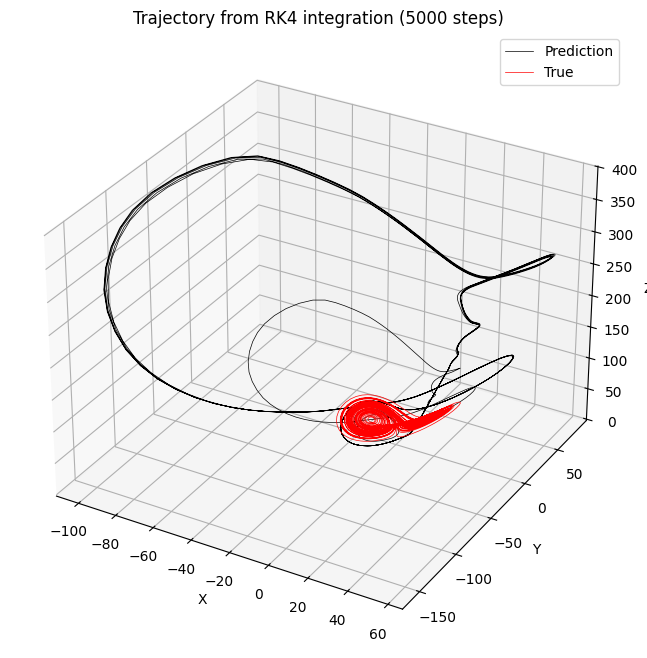

In [13]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # required for 3d plotting

model.eval();
model.to('cpu');

# Assume model is an instance of your network (with RK4 forward) and is already defined.
# Set the model to eval mode and push it to the proper device.
device = 'cpu'
model.to(device)
model.eval()

data = np.concatenate((data_train[-1].reshape(1,3),data_test),axis=0)
print(data.shape)

# Define the initial condition as a torch tensor (shape: (1, 3)) and move it to the device
state = torch.tensor([data[0]], device=device)

# We'll store all the states as numpy arrays for plotting.
states = []

# Append the initial state
states.append(state.cpu().detach().numpy().flatten())

# Apply the network 5000 times iteratively.
num_steps = 5000
with torch.no_grad():  # deactivate gradients for inference
    for _ in range(num_steps):
        state = model(state.float())
        states.append(state.cpu().detach().numpy().flatten())

# Convert states to a numpy array (shape will be (5001, 3))
states = np.array(states)

# Set up a 3D plot using matplotlib.
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot the trajectory
ax.plot(states[:, 0], states[:, 1], states[:, 2], 'k-', lw=0.5, label="Prediction")
ax.plot(data[:,0],data[:,1],data[:,2],'r-', lw=0.5, label="True")
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
ax.set_title("Trajectory from RK4 integration (5000 steps)")
ax.legend()
plt.show()

In [14]:
time = np.linspace(0,500,5001)

In [15]:
#Fixing the configuration for the plots
plt.rcParams["figure.dpi"] = 300
plt.rcParams["text.usetex"] = True
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.size"] = 10
plt.rcParams["figure.figsize"] = (4.5, 2)

In [16]:
data.shape, states.shape

((5001, 3), (5001, 3))

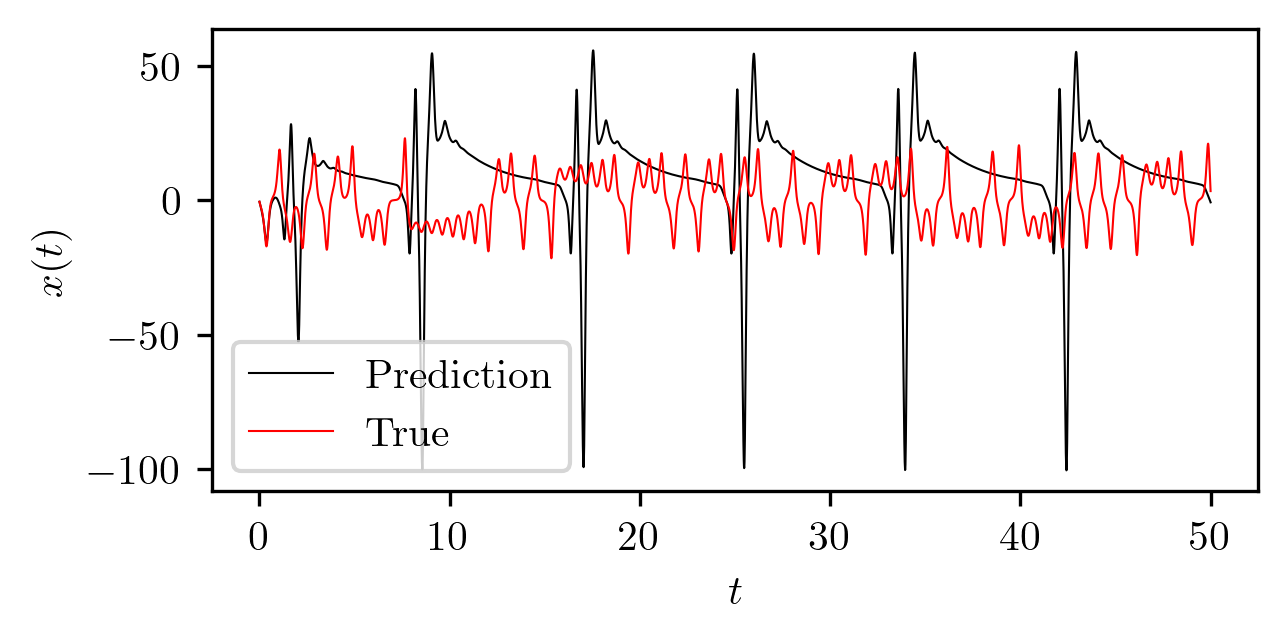

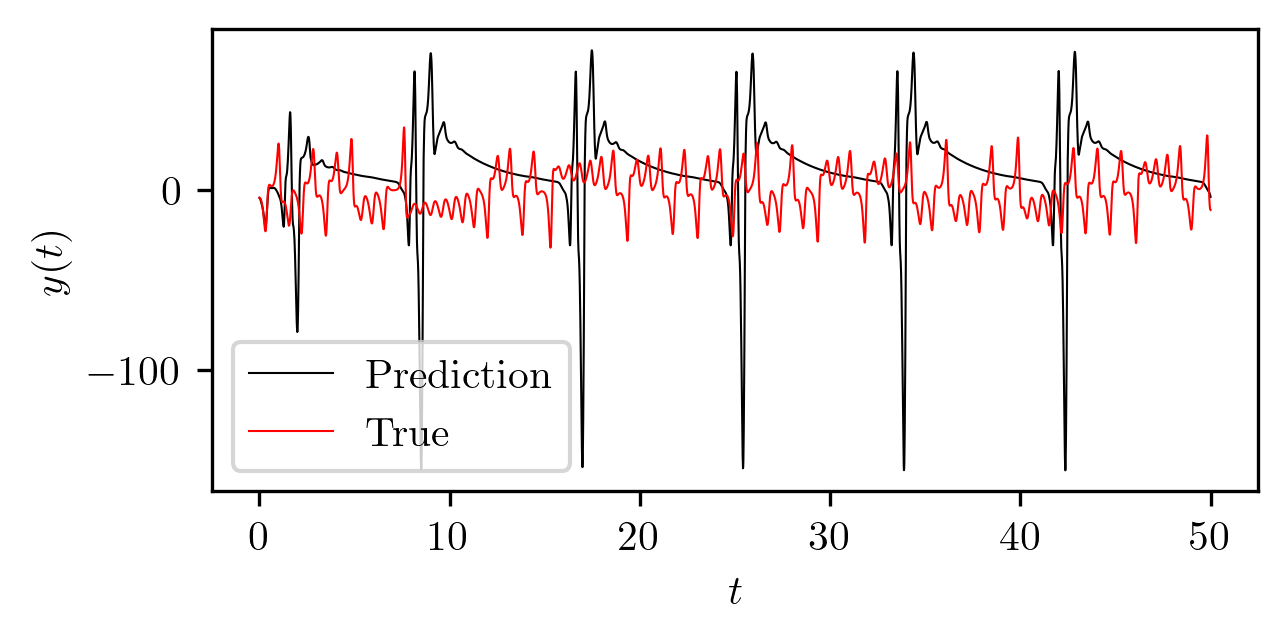

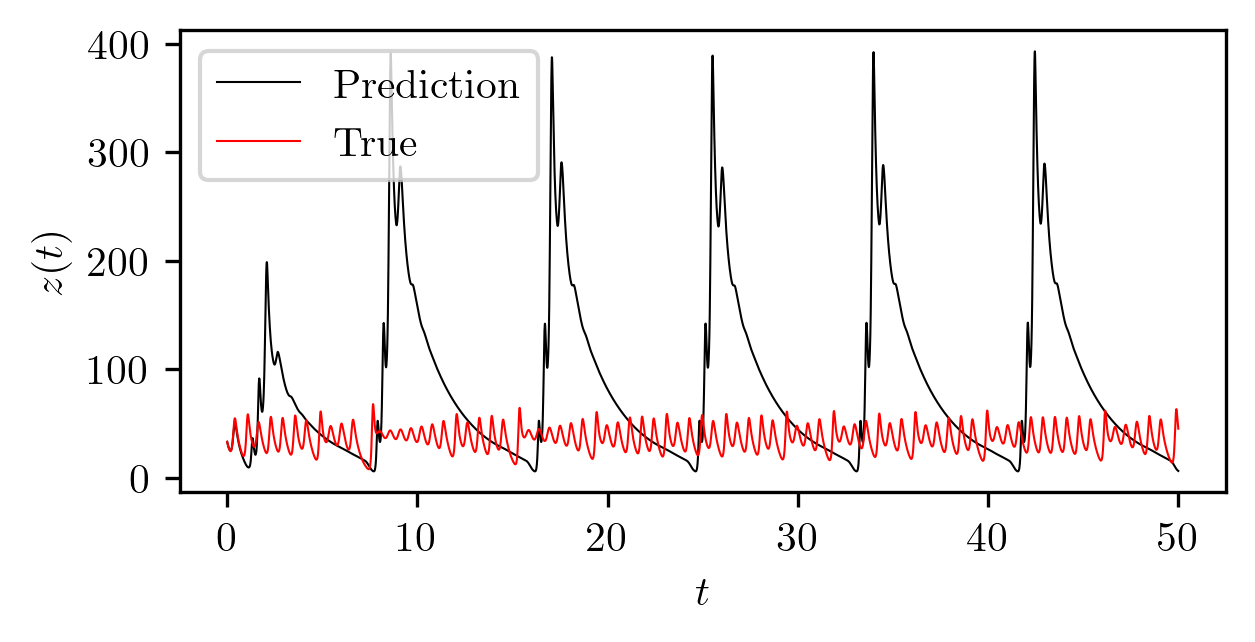

In [17]:
time = np.linspace(0,50,5001)
plt.plot(time,states[:, 0],'k-',label="Prediction",lw=0.5)
plt.plot(time,data[:, 0],'r-',label="True",lw=0.5)
plt.ylabel(r"$x(t)$")
plt.xlabel(r"$t$")
plt.legend()
plt.show();

fig = plt.figure()
plt.plot(time,states[:, 1],'k-',label="Prediction",lw=0.5)
plt.plot(time,data[:, 1],'r-',label="True",lw=0.5)
plt.xlabel(r"$t$")
plt.ylabel(r"$y(t)$")
plt.legend()
plt.show();

fig = plt.figure()
plt.plot(time,states[:, 2],'k-',label="Prediction",lw=0.5)
plt.plot(time,data[:, 2],'r-',label="True",lw=0.5)
plt.xlabel(r"$t$")
plt.ylabel(r"$z(t)$")
plt.legend()
plt.show();

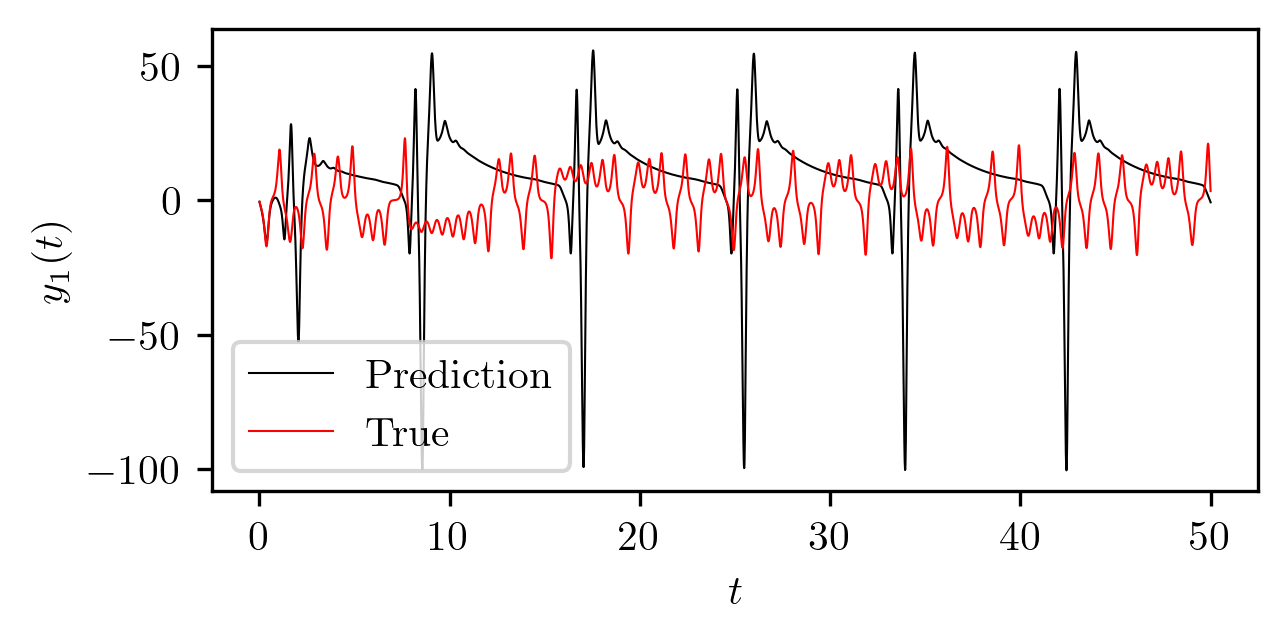

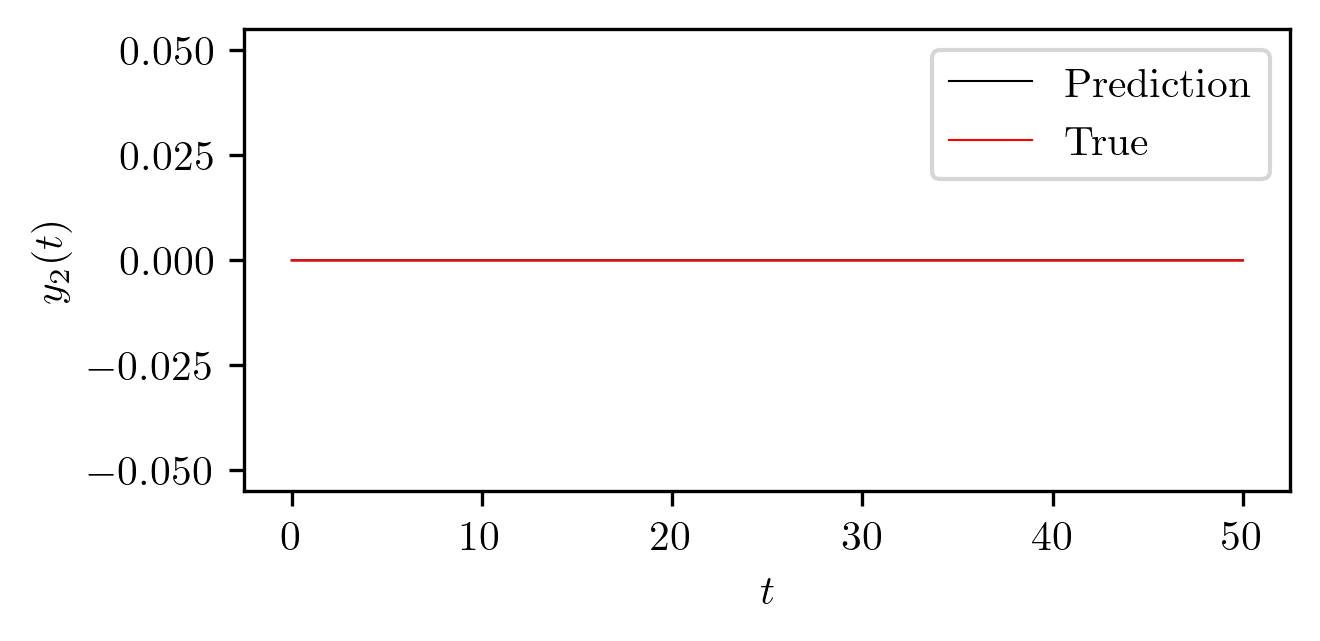

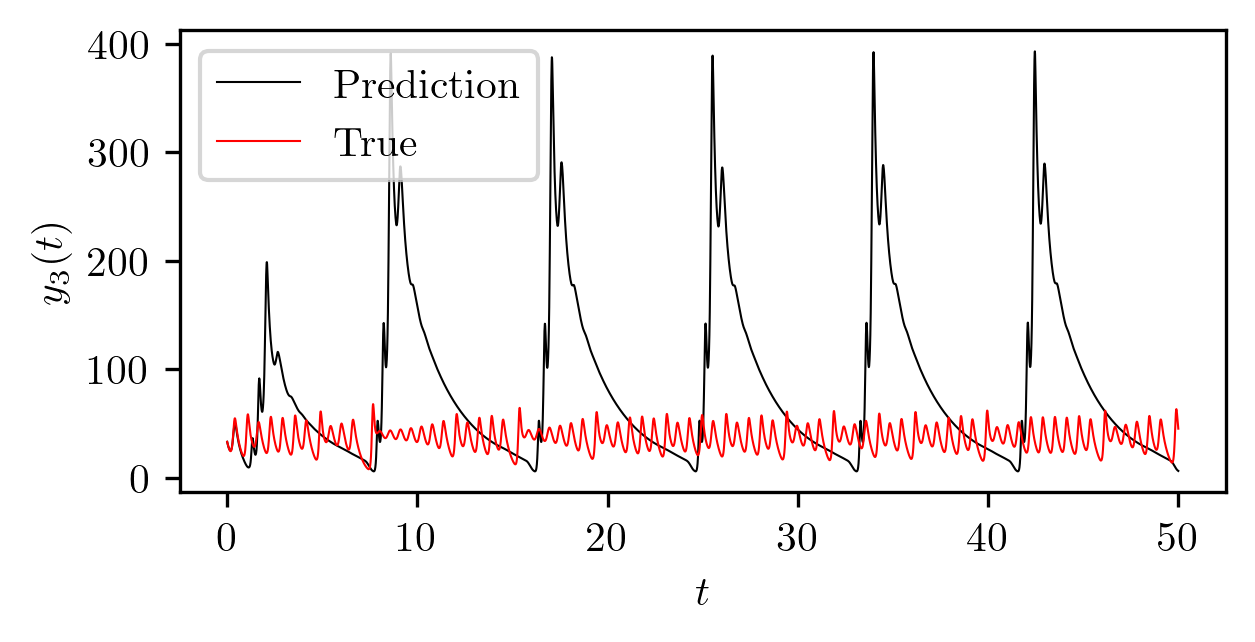

In [25]:
proj_state = states @ A.detach().cpu().numpy()
proj_data = data @ A.detach().cpu().numpy()

_,d = states.shape

for i in range(d):
    time = np.linspace(0,50,5001)
    plt.plot(time,proj_state[:, i],'k-',label="Prediction",lw=0.5)
    plt.plot(time,proj_data[:, i],'r-',label="True",lw=0.5)
    plt.ylabel(rf"$y_{i+1}(t)$")
    plt.xlabel(r"$t$")
    plt.legend()
    plt.show();


In [19]:
states.shape

(5001, 3)

In [20]:
states[1]

array([-0.85788321, -4.15010452, 32.26136017])

In [21]:
data_test[0]

array([-0.85705945, -4.10394583, 32.26398411])

In [22]:
np.save('lorenz_prediction.npy', states[1:])

In [23]:
cc = np.load("lorenz_prediction.npy")
cc.shape

(5000, 3)